# EDA — Bank Marketing

## Objetivo

Explorar os dados do **Bank Marketing** para entender:

- a distribuição da variável alvo `y`;
- a qualidade e estrutura dos dados;
- `contact` como **braço** da estratégia de contato;
- `y` como **recompensa**;
- quais características de contexto estão associadas à conversão;
- se a performance de `cellular` e `telephone` varia entre segmentos;
- quais diferenças parecem consistentes e quais podem ser explicadas por baixo volume amostral.

> **Regra importante:** a análise considera apenas informações disponíveis antes da nova interação. A coluna `duration` será removida por representar informação obtida após a chamada.

Obs: Notebook foi criado anteriormente e foi pedido para a IA organizar o código e os comentários

## 1. Imports e configurações

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Leitura dos dados

In [32]:
df = pd.read_csv("../data/raw/bank-additional-full.csv",sep=";")

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Linhas: 41,188
Colunas: 21


In [33]:
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


## 3. Entendendo as variáveis

### Variáveis do cliente

- `age`: idade
- `job`: profissão
- `marital`: estado civil
- `education`: nível de educação
- `default`: possui crédito em default
- `housing`: possui financiamento imobiliário
- `loan`: possui empréstimo pessoal

### Variáveis relacionadas ao contato/campanha

- `contact`: tipo de contato (`cellular` ou `telephone`)
- `month`, `day_of_week`: momento do contato
- `campaign`: número de contatos realizados durante a campanha
- `duration`: duração do último contato

### Histórico

- `pdays`: dias desde o último contato de campanha anterior
- `previous`: número de contatos realizados antes desta campanha
- `poutcome`: resultado da campanha anterior

### Contexto econômico

- `emp.var.rate`
- `cons.price.idx`
- `euribor3m`
- `nr.employed`

### Variável alvo

- `y`: adesão ao produto (`yes` / `no`)

## 4. Qualidade e estrutura dos dados

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [35]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "n_unicos": df.nunique(),
    "percentual_nulos": df.isna().mean() * 100
})

qualidade

,tipo,nulos,n_unicos,percentual_nulos
age,int64,0,78,0.00
job,str,0,12,0.00
marital,str,0,4,0.00
education,str,0,8,0.00
default,str,0,3,0.00
housing,str,0,3,0.00
loan,str,0,3,0.00
contact,str,0,2,0.00
month,str,0,10,0.00
day_of_week,str,0,5,0.00


In [36]:
print(f"Duplicatas: {df.duplicated().sum():,}")

Duplicatas: 12


In [61]:
df = df.drop_duplicates()
df.shape

(41176, 21)

In [62]:
# Valores explicitamente representados como "unknown"
unknowns = (
    df.astype(str)
      .apply(lambda col: col.str.lower().eq("unknown").sum())
      .sort_values(ascending=False)
)

unknowns[unknowns > 0]

default      8596
education    1730
housing       990
loan          990
job           330
marital        80
dtype: int64

### Observação sobre qualidade

O dataset utiliza `unknown` em algumas variáveis categóricas. Isso não deve ser automaticamente tratado como nulo: no contexto da análise, o valor representa uma categoria sem informação conhecida.

A etapa de limpeza/preprocessamento definitiva ficará no `src/`

## 5. Variável alvo — `y`

In [63]:
target = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100

pd.DataFrame({
    "quantidade": target,
    "percentual": target_pct
})

,quantidade,percentual
y,,
no,36537,88.73
yes,4639,11.27


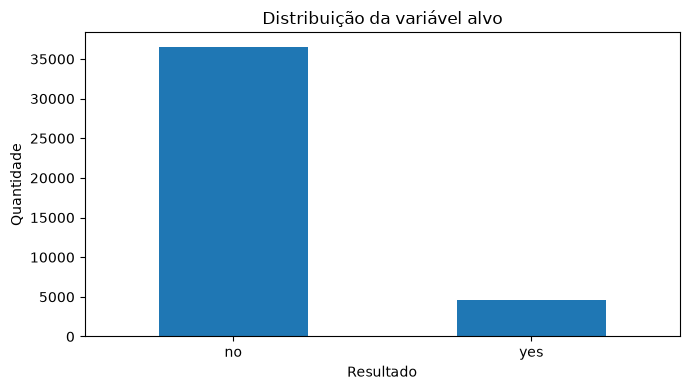

In [64]:
target.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.xlabel("Resultado")
plt.ylabel("Quantidade")
plt.title("Distribuição da variável alvo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Definição do problema de experimentação

### Contexto, braço e recompensa

**Contexto:** informações disponíveis antes da nova interação.

- Cliente: `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`
- Histórico: `pdays`, `previous`, `poutcome`, `campaign`
- Contexto econômico: `emp.var.rate`, `cons.price.idx`, `euribor3m`, `nr.employed`

**Braços (`arm`):**

- `cellular`
- `telephone`

Representados pela variável `contact`.

**Recompensa (`reward`):**

- `y = yes` → `1`
- `y = no` → `0`

O objetivo do estudo é verificar se existe evidência de que a escolha do braço deve depender do contexto do cliente.

## 7. `duration`: variável que não pode entrar na decisão

In [65]:
df = df.drop(columns=["duration"])

print("Coluna duration removida.")
print(f"Quantidade de colunas: {df.shape[1]}")

Coluna duration removida.
Quantidade de colunas: 20


## 8. Visão geral dos braços

In [66]:
arm_summary = (
    df.assign(yes=df["y"].eq("yes"))
      .groupby("contact")
      .agg(
          contatos=("y", "size"),
          yes=("yes", "sum"),
          taxa_yes=("yes", "mean")
      )
)

arm_summary["taxa_yes"] *= 100
arm_summary.sort_values("taxa_yes", ascending=False)

,contatos,yes,taxa_yes
contact,,,
cellular,26135,3852,14.74
telephone,15041,787,5.23


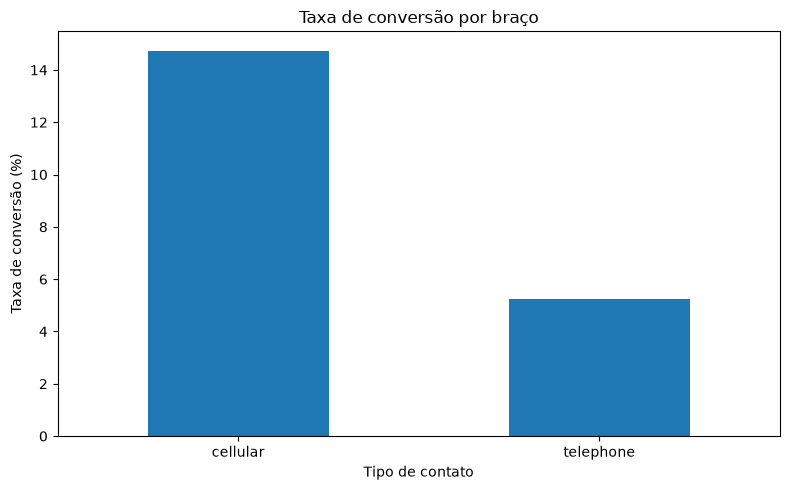

In [67]:
arm_summary["taxa_yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Tipo de contato")
plt.ylabel("Taxa de conversão (%)")
plt.title("Taxa de conversão por braço")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

`cellular` apresenta a maior taxa de conversão global e, por isso, é um candidato natural a **baseline**.

Isso, porém, não significa que `cellular` seja necessariamente o melhor braço para todos os clientes. A partir daqui, a análise procura identificar heterogeneidade por contexto.

## 9. Braço × profissão

In [68]:
taxa_job = pd.crosstab(
    df["job"],
    df["contact"],
    values=df["y"].eq("yes"),
    aggfunc="mean"
) * 100

taxa_job

contact,cellular,telephone
job,,
admin.,16.26,5.86
blue-collar,9.02,4.30
entrepreneur,10.41,5.82
housemaid,12.97,5.48
management,14.41,5.28
retired,31.60,9.24
self-employed,14.45,3.79
services,11.00,4.16
student,36.36,15.20


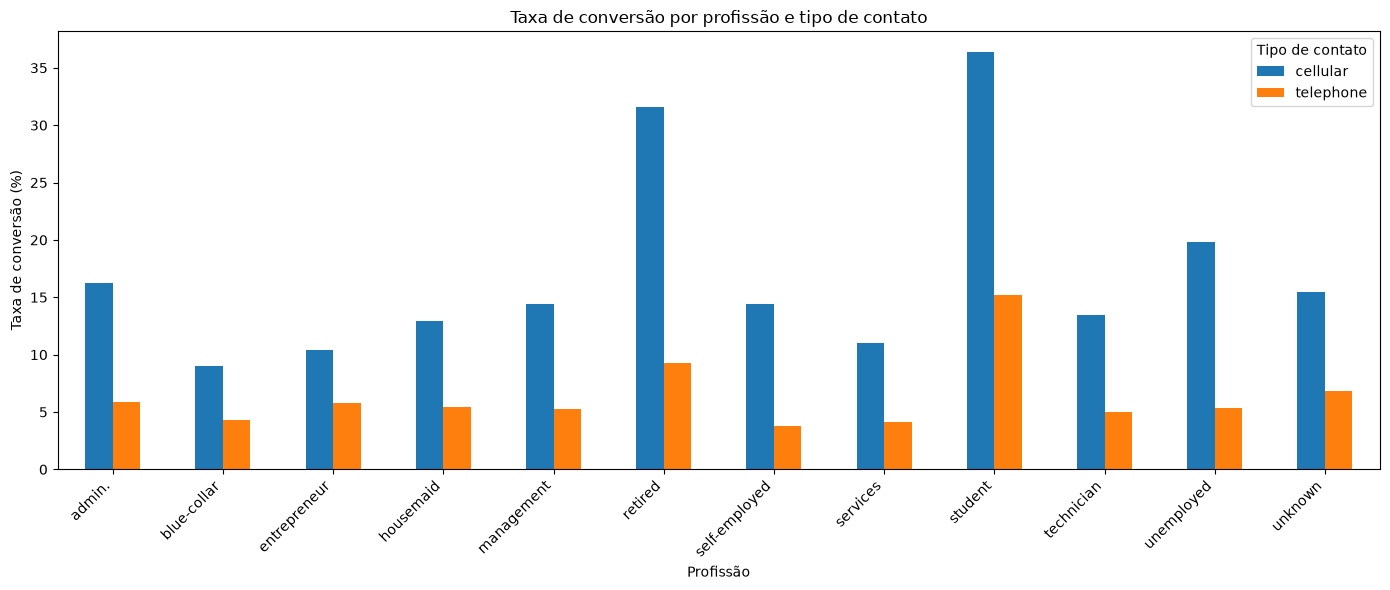

In [69]:
taxa_job.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("Profissão")
plt.ylabel("Taxa de conversão (%)")
plt.title("Taxa de conversão por profissão e tipo de contato")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de contato")
plt.tight_layout()
plt.show()

A análise por `job` indica que a vantagem de `cellular` observada globalmente também aparece de forma consistente entre as categorias de profissão.

## 10. Braço × idade

In [70]:
taxa_age = pd.crosstab(
    df["age"],
    df["contact"],
    values=df["y"].eq("yes"),
    aggfunc="mean"
) * 100

taxa_age.head(10)

contact,cellular,telephone
age,,
17,40.00,NaN
18,45.45,33.33
19,47.37,50.00
20,42.31,7.69
21,32.18,6.67
22,32.99,10.00
23,24.19,7.50
24,23.01,6.50
25,20.11,8.00


In [71]:
bins = [0, 25, 35, 45, 55, 65, 75, 100]
labels = [
    "Até 25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66-75",
    "76+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

In [72]:
analise_age = (
    df.assign(yes=df["y"].eq("yes"))
      .groupby(["age_group", "contact"], observed=True)
      .agg(
          contatos=("y", "size"),
          yes=("yes", "sum")
      )
)

analise_age["taxa_yes"] = (
    analise_age["yes"] / analise_age["contatos"] * 100
)

analise_age

contatos   yes  taxa_yes
age_group contact                            
Até 25    cellular       1199   310     25.85
          telephone       466    39      8.37
26-35     cellular       9842  1463     14.86
          telephone      5002   277      5.54
36-45     cellular       7529   845     11.22
          telephone      5310   247      4.65
46-55     cellular       5109   580     11.35
          telephone      3138   137      4.37
56-65     cellular       1904   386     20.27
          telephone      1059    65      6.14
66-75     cellular        325   151     46.46
          telephone        48    10     20.83
76+       cellular        227   117     51.54
          telephone        18    12     66.67

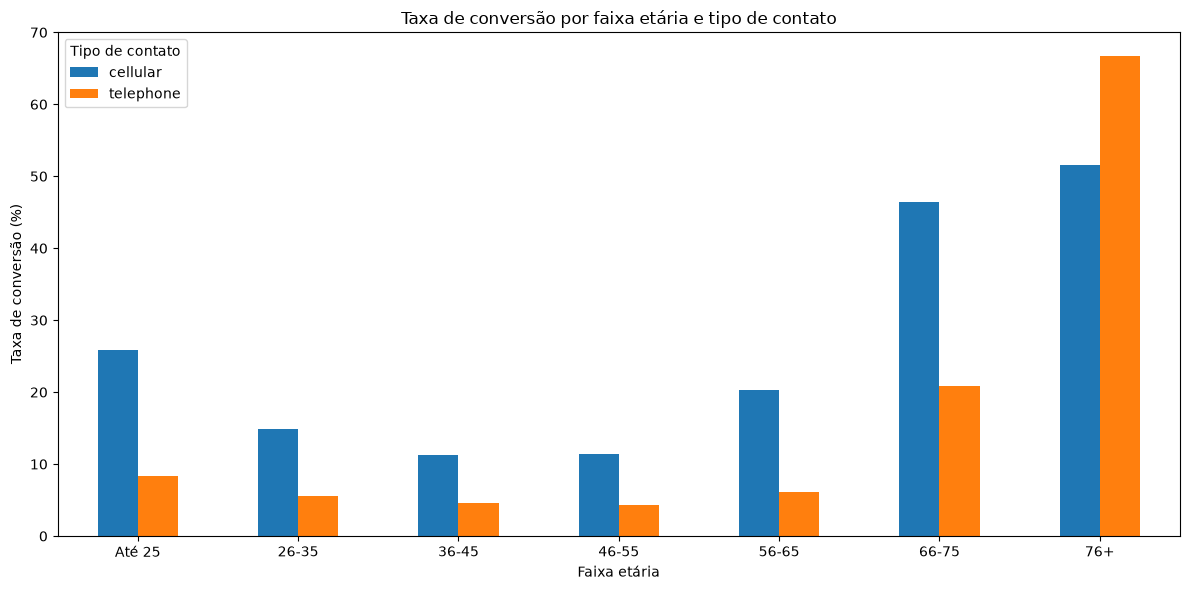

In [73]:
taxa_age_group = analise_age["taxa_yes"].unstack()

taxa_age_group.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Faixa etária")
plt.ylabel("Taxa de conversão (%)")
plt.title("Taxa de conversão por faixa etária e tipo de contato")
plt.xticks(rotation=0)
plt.legend(title="Tipo de contato")
plt.tight_layout()
plt.show()

`cellular` apresenta maior taxa de conversão na maioria das faixas etárias.

Na faixa `76+`, `telephone` pode aparecer à frente, mas o volume de observações é muito menor. Portanto, esse tipo de inversão precisa ser avaliado junto com o tamanho da amostra e os intervalos de confiança.

## 11. `poutcome`: histórico da campanha anterior

In [74]:
poutcome_summary = (
    df.groupby("poutcome")["y"]
      .agg(
          contatos="count",
          yes=lambda x: (x == "yes").sum(),
          taxa_yes=lambda x: (x == "yes").mean() * 100
      )
      .sort_values("taxa_yes", ascending=False)
)

poutcome_summary

,contatos,yes,taxa_yes
poutcome,,,
success,1373,894,65.11
failure,4252,605,14.23
nonexistent,35551,3140,8.83


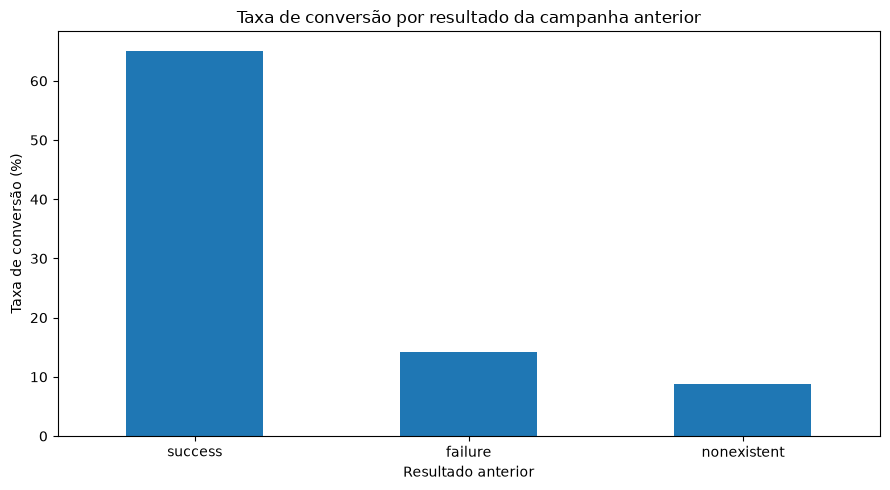

In [75]:
poutcome_summary["taxa_yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Resultado anterior")
plt.ylabel("Taxa de conversão (%)")
plt.title("Taxa de conversão por resultado da campanha anterior")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

`poutcome` apresenta uma diferença relevante na taxa de conversão. Clientes cujo histórico anterior foi classificado como `success` possuem taxa de `yes` muito superior às demais categorias.

Isso torna `poutcome` uma variável de contexto especialmente importante para a estratégia de escolha do braço.

## 12. `poutcome` × `contact`

In [76]:
taxa_poutcome = pd.crosstab(
    df["poutcome"],
    df["contact"],
    values=df["y"].eq("yes"),
    aggfunc="mean"
) * 100

taxa_poutcome

contact,cellular,telephone
poutcome,,
failure,14.45,11.33
nonexistent,11.73,4.69
success,65.20,64.08


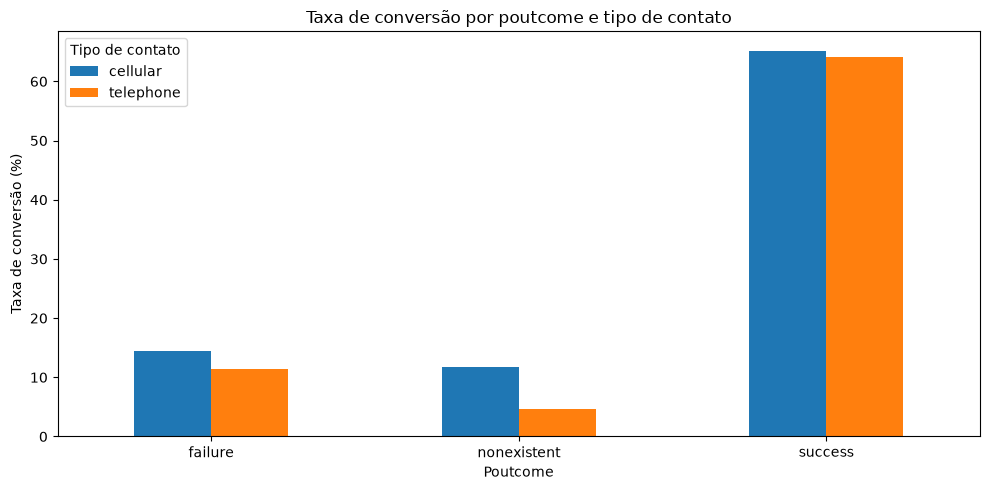

In [77]:
taxa_poutcome.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Poutcome")
plt.ylabel("Taxa de conversão (%)")
plt.title("Taxa de conversão por poutcome e tipo de contato")
plt.xticks(rotation=0)
plt.legend(title="Tipo de contato")
plt.tight_layout()
plt.show()

A diferença entre os braços deve, portanto, ser analisada dentro dos grupos de `poutcome`, e não apenas pela taxa global.

## 13. `poutcome` × faixa etária × `contact`

In [78]:
analise_segmentos = (
    df.assign(yes=df["y"].eq("yes"))
      .groupby(
          ["poutcome", "age_group", "contact"],
          observed=True
      )
      .agg(
          contatos=("y", "size"),
          yes=("yes", "sum")
      )
      .reset_index()
)

analise_segmentos["taxa_yes"] = (
    analise_segmentos["yes"]
    / analise_segmentos["contatos"]
    * 100
)

analise_segmentos

,poutcome,age_group,contact,contatos,yes,taxa_yes
0,failure,Até 25,cellular,204,56,27.45
1,failure,Até 25,telephone,16,2,12.50
2,failure,26-35,cellular,1490,185,12.42
3,failure,26-35,telephone,134,14,10.45
4,failure,36-45,cellular,1153,129,11.19
5,failure,36-45,telephone,75,9,12.00
6,failure,46-55,cellular,701,89,12.70
7,failure,46-55,telephone,48,3,6.25
8,failure,56-65,cellular,266,65,24.44
9,failure,56-65,telephone,17,4,23.53


In [79]:
comparacao = analise_segmentos.pivot(
    index=["poutcome", "age_group"],
    columns="contact",
    values=["contatos", "yes", "taxa_yes"]
)

comparacao

contatos                yes           taxa_yes          
contact               cellular telephone cellular telephone cellular telephone
poutcome    age_group                                                         
failure     Até 25      204.00     16.00    56.00      2.00    27.45     12.50
            26-35     1,490.00    134.00   185.00     14.00    12.42     10.45
            36-45     1,153.00     75.00   129.00      9.00    11.19     12.00
            46-55       701.00     48.00    89.00      3.00    12.70      6.25
            56-65       266.00     17.00    65.00      4.00    24.44     23.53
            66-75        83.00     10.00    28.00      2.00    33.73     20.00
            76+          55.00       NaN    19.00       NaN    34.55       NaN
nonexistent Até 25      885.00    439.00   181.00     29.00    20.45      6.61
            26-35     7,907.00  4,831.00 1,001.00    242.00    12.66      5.01
            36-45     6,111.00  5,214.00   546.00    224.00     8.93      4.30
            46-55     4,225.00  3,071.00   380.00    122.00     8.99      3.97
            56-65     1,483.00  1,034.00   210.00     55.00    14.16      5.32
            66-75       186.00     34.00    83.00      6.00    44.62     17.65
            76+         116.00     15.00    52.00      9.00    44.83     60.00
success     Até 25      110.00     11.00    73.00      8.00    66.36     72.73
            26-35       445.00     37.00   277.00     21.00    62.25     56.76
            36-45       265.00     21.00   170.00     14.00    64.15     66.67
            46-55       183.00     19.00   111.00     12.00    60.66     63.16
            56-65       155.00      8.00   111.00      6.00    71.61     75.00
            66-75        56.00      4.00    40.00      2.00    71.43     50.00
            76+          56.00      3.00    46.00      3.00    82.14    100.00

In [80]:
taxas = (
    analise_segmentos
    .pivot(
        index=["poutcome", "age_group"],
        columns="contact",
        values="taxa_yes"
    )
    .reset_index()
)

taxas["diferenca_pp"] = (
    taxas["cellular"] - taxas["telephone"]
)

taxas.sort_values("diferenca_pp")

contact,poutcome,age_group,cellular,telephone,diferenca_pp
20,success,76+,82.14,100.00,-17.86
13,nonexistent,76+,44.83,60.00,-15.17
14,success,Até 25,66.36,72.73,-6.36
18,success,56-65,71.61,75.00,-3.39
16,success,36-45,64.15,66.67,-2.52
17,success,46-55,60.66,63.16,-2.50
2,failure,36-45,11.19,12.00,-0.81
4,failure,56-65,24.44,23.53,0.91
1,failure,26-35,12.42,10.45,1.97
9,nonexistent,36-45,8.93,4.30,4.64


A análise conjunta mostra que a performance dos braços não é uniforme em todos os segmentos.

`cellular` permanece superior na maior parte dos segmentos com maior volume de observações, mas aparecem inversões em grupos pequenos. Essas inversões não devem ser interpretadas isoladamente como evidência de superioridade do `telephone`.

## 14. Intervalos de confiança de Wilson

Para comparar taxas de conversão entre segmentos, além da taxa observada, vamos considerar a incerteza da estimativa.

O intervalo de Wilson é utilizado aqui para proporções, especialmente porque alguns segmentos possuem poucos contatos.

In [81]:
def calcular_ic_wilson(row, alpha=0.05):
    limite_inf, limite_sup = proportion_confint(
        count=row["yes"],
        nobs=row["contatos"],
        alpha=alpha,
        method="wilson"
    )

    return pd.Series({
        "ic_inf": limite_inf * 100,
        "ic_sup": limite_sup * 100
    })

ic = analise_segmentos.apply(
    calcular_ic_wilson,
    axis=1
)

analise_ic = pd.concat(
    [analise_segmentos, ic],
    axis=1
)

analise_ic

,poutcome,age_group,contact,contatos,yes,taxa_yes,ic_inf,ic_sup
0,failure,Até 25,cellular,204,56,27.45,21.79,33.95
1,failure,Até 25,telephone,16,2,12.50,3.50,36.02
2,failure,26-35,cellular,1490,185,12.42,10.84,14.19
3,failure,26-35,telephone,134,14,10.45,6.33,16.77
4,failure,36-45,cellular,1153,129,11.19,9.50,13.14
5,failure,36-45,telephone,75,9,12.00,6.44,21.26
6,failure,46-55,cellular,701,89,12.70,10.43,15.37
7,failure,46-55,telephone,48,3,6.25,2.15,16.84
8,failure,56-65,cellular,266,65,24.44,19.66,29.94
9,failure,56-65,telephone,17,4,23.53,9.56,47.26


In [82]:
comparacao_ic = (
    analise_ic
    .pivot(
        index=["poutcome", "age_group"],
        columns="contact",
        values=["taxa_yes", "ic_inf", "ic_sup", "contatos"]
    )
)

comparacao_ic

taxa_yes             ic_inf             ic_sup  \
contact               cellular telephone cellular telephone cellular   
poutcome    age_group                                                  
failure     Até 25       27.45     12.50    21.79      3.50    33.95   
            26-35        12.42     10.45    10.84      6.33    14.19   
            36-45        11.19     12.00     9.50      6.44    13.14   
            46-55        12.70      6.25    10.43      2.15    15.37   
            56-65        24.44     23.53    19.66      9.56    29.94   
            66-75        33.73     20.00    24.48      5.67    44.42   
            76+          34.55       NaN    23.36       NaN    47.75   
nonexistent Até 25       20.45      6.61    17.92      4.64    23.23   
            26-35        12.66      5.01    11.94      4.43    13.41   
            36-45         8.93      4.30     8.25      3.78     9.68   
            46-55         8.99      3.97     8.17      3.34     9.89   
            56-65        14.16      5.32    12.48      4.11    16.03   
            66-75        44.62     17.65    37.66      8.35    51.80   
            76+          44.83     60.00    36.09     35.75    53.90   
success     Até 25       66.36     72.73    57.11     43.44    74.51   
            26-35        62.25     56.76    57.66     40.91    66.63   
            36-45        64.15     66.67    58.21     45.37    69.68   
            46-55        60.66     63.16    53.43     41.04    67.44   
            56-65        71.61     75.00    64.06     40.93    78.12   
            66-75        71.43     50.00    58.52     15.00    81.58   
            76+          82.14    100.00    70.16     43.85    90.00   

                                contatos            
contact               telephone cellular telephone  
poutcome    age_group                               
failure     Até 25        36.02   204.00     16.00  
            26-35         16.77 1,490.00    134.00  
            36-45         21.26 1,153.00     75.00  
            46-55         16.84   701.00     48.00  
            56-65         47.26   266.00     17.00  
            66-75         50.98    83.00     10.00  
            76+             NaN    55.00       NaN  
nonexistent Até 25         9.33   885.00    439.00  
            26-35          5.66 7,907.00  4,831.00  
            36-45          4.88 6,111.00  5,214.00  
            46-55          4.72 4,225.00  3,071.00  
            56-65          6.86 1,483.00  1,034.00  
            66-75         33.51   186.00     34.00  
            76+           80.18   116.00     15.00  
success     Até 25        90.25   110.00     11.00  
            26-35         71.33   445.00     37.00  
            36-45         82.81   265.00     21.00  
            46-55         80.85   183.00     19.00  
            56-65         92.85   155.00      8.00  
            66-75         85.00    56.00      4.00  
            76+          100.00    56.00      3.00

Os intervalos de confiança tornam evidente um ponto importante: taxas muito altas em segmentos com poucos contatos podem possuir grande incerteza.

## 15. Comparação estatística entre os braços por segmento

In [83]:
def teste_proporcoes(grupo):
    if len(grupo) != 2:
        return np.nan

    sucessos = grupo["yes"].values
    contatos = grupo["contatos"].values

    _, p_valor = proportions_ztest(
        sucessos,
        contatos
    )

    return p_valor

p_values = (
    analise_ic
    .groupby(["poutcome", "age_group"], observed=True)
    .apply(teste_proporcoes)
    .reset_index(name="p_valor")
)

p_values["significativo"] = p_values["p_valor"] < 0.05

p_values

,poutcome,age_group,p_valor,significativo
0,failure,Até 25,0.19,False
1,failure,26-35,0.51,False
2,failure,36-45,0.83,False
3,failure,46-55,0.19,False
4,failure,56-65,0.93,False
5,failure,66-75,0.38,False
6,failure,76+,NaN,False
7,nonexistent,Até 25,0.00,True
8,nonexistent,26-35,0.00,True
9,nonexistent,36-45,0.00,True


## 16. Outras variáveis categóricas

In [89]:
categoricas = [
    "job",
    "education",
    "marital",
    "housing",
    "loan",
    "default"
]

resultados_categoricas = {}

for coluna in categoricas:
    resultados_categoricas[coluna] = (
        pd.crosstab(
            df[coluna],
            df["contact"],
            values=df["y"].eq("yes"),
            aggfunc="mean"
        ) * 100
    )

resultados_categoricas["job"]

contact,cellular,telephone
job,,
admin.,16.26,5.86
blue-collar,9.02,4.30
entrepreneur,10.41,5.82
housemaid,12.97,5.48
management,14.41,5.28
retired,31.60,9.24
self-employed,14.45,3.79
services,11.00,4.16
student,36.36,15.20


In [87]:
resultados_categoricas["education"]

contact,cellular,telephone
education,,
basic.4y,14.89,4.27
basic.6y,11.07,4.79
basic.9y,10.54,4.20
high.school,14.30,5.13
illiterate,20.00,33.33
professional.course,14.59,4.99
university.degree,16.61,6.61
unknown,20.26,6.31


In [ ]:
resultados_categoricas["marital"]

contact,cellular,telephone
marital,,
divorced,13.65,4.64
married,13.53,4.88
single,17.39,6.49
unknown,20.75,3.70


In [ ]:
resultados_categoricas["housing"]

contact,cellular,telephone
housing,,
no,14.76,5.22
unknown,16.40,3.50
yes,14.66,5.35


In [ ]:
resultados_categoricas["loan"]

contact,cellular,telephone
loan,,
no,14.82,5.31
unknown,16.40,3.50
yes,14.06,5.12


In [ ]:
resultados_categoricas["default"]

contact,cellular,telephone
default,,
no,16.36,5.87
unknown,6.67,3.59
yes,0.00,NaN


## 18. Síntese dos achados do EDA

### Principais conclusões

1. **`cellular` é o melhor baseline global:** apresenta maior taxa de conversão que `telephone` no conjunto completo.

2. **A escolha do braço não deve ser analisada apenas globalmente:** a performance varia de acordo com características do cliente.

3. **`poutcome` é um dos principais sinais de contexto:** o histórico da campanha anterior está fortemente associado à probabilidade de conversão.

4. **Idade também modifica o comportamento observado:** `cellular` fica à frente na maioria das faixas, enquanto algumas inversões aparecem em grupos com poucos contatos.

5. **Baixo volume gera estimativas instáveis:** taxas como 100% em pequenos segmentos não são suficientes, sozinhas, para definir uma estratégia.

6. **Existe evidência exploratória de heterogeneidade:** alguns segmentos tornam `telephone` competitivo, indicando potencial para uma política que considere contexto.

7. **Próxima etapa:** construir os baselines e, depois, avaliar Thompson Sampling/contextual Thompson Sampling em uma etapa separada do EDA.